# Cardiac HH Models: Ventricular vs. SA Node (HH alpha–beta gates)

**Goal.** Build two didactic Hodgkin–Huxley (HH)-type membrane models that highlight key electrophysiological differences between **ventricular myocytes** and **sinoatrial (SA) node pacemaker cells**. We use voltage- and time-dependent **alpha–beta** gate dynamics (no instantaneous sigmoids), and minimal current sets that still reproduce (i) a fast **upstroke + plateau** (ventricle) and (ii) **spontaneous diastolic depolarization** (SA node).

> Educational simplification inspired by Beeler–Reuter (ventricular) and Yanagihara–Noma–Irisawa (SAN). See references at the end.


## Background (concepts used here)

- **Ventricular cells**: prominent fast **Na⁺ current** (rapid phase‑0 upstroke), strong **IK1** stabilizes a negative resting potential, **ICaL** creates a plateau, and delayed rectifier **IK** mediates repolarization.

- **SA node cells**: lack (or have minimal) fast Na⁺ current; upstroke is largely **Ca²⁺‑mediated (ICaL)**; have **If** (HCN "funny current") activating on **hyperpolarization** that drives diastolic depolarization; **IK1** is small/absent.

- **HH gating**: for each gate $x\in\{m,h,n,\dots\}$ we evolve $\dot x = alpha_x(V)\,(1-x) - beta_x(V)\,x$, so that $x_\infty=alpha/(alpha+beta)$ and $	au_x=1/(alpha+beta)$.


## Imports & constants


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Physical constants
R = 8.314   # J/(mol·K)
T = 310.0   # K (≈37°C)
F = 96485.0 # C/mol

# Helper: Nernst (mV)
def nernst_mV(out_mM, in_mM, z):
    return (R*T)/(z*F)*np.log(out_mM/in_mM)*1000.0

# Default extracellular/intracellular concentrations (mM)
Na_o, Na_i = 140.0, 10.0
K_o,  K_i  = 5.4,  145.0
Ca_o, Ca_i = 1.8,  0.0001

E_Na = nernst_mV(Na_o, Na_i, z=1)
E_K  = nernst_mV(K_o,  K_i,  z=1)
E_Ca = nernst_mV(Ca_o, Ca_i, z=2)
E_L  = -60.0  # generic leak reversal (mV)
E_f  = -20.0  # funny current mixed Na/K reversal (mV)

Cm = 1.0   # µF/cm^2

E_Na, E_K, E_Ca, E_f


(np.float64(70.49539325191057),
 np.float64(-87.89253733425454),
 np.float64(130.86544404429665),
 -20.0)

## HH alpha–beta helpers
We define a small set of **alpha–beta templates** used to build voltage-dependent gates. These give reasonable cardiac-like $x_\infty(V)$ and $	au_x(V)$ curves while keeping the code compact.


In [2]:
def ab_explinear(V, A, B, C):
    """
    An "exp-linear" style term: A*(V+B)/(1 - exp(-(V+B)/C)) with l'Hospital handling.
    Commonly used in HH-type fits (e.g., Beeler-Reuter/Luo-Rudy style).
    """
    x = (V + B)/C
    # Avoid division by zero near x=0
    return A*(V+B)/(1 - np.exp(-x) + 1e-12)

def ab_exp(V, A, B):
    return A*np.exp(-(V+B))

def ab_logistic(V, A, B):
    # Scaled logistic slope around -B
    return A/(1 + np.exp((V + B)))

def hh_update(x, V, alpha, beta, dt):
    # Forward Euler for one gate variable
    return x + dt*(alpha*(1-x) - beta*x)


## Model definitions
We create two models by composing currents. Each current is of the form $I = g(V,t)\,(V-E)$. Gates follow $\dot x = \alpha _x(V)(1-x) - \beta _x(V)x$.

**Ventricular model currents** (didactic subset):
- Fast $I_{Na}$ with gates $m,h$ (rapid upstroke).
- L-type calcium $I_{CaL}$ with gates $d,f$ (plateau).
- Delayed rectifier $I_{K}$ with gate $n$ (repolarization).
- Inward rectifier $I_{K1}$ (time-independent, stabilizes rest).
- Leak $I_L$.

**SA node model currents** (didactic subset):
- Minimal/absent fast $I_{Na}$ (small $ar g_{Na}$).
- $I_{CaL}$ ($d,f$) for upstroke.
- Delayed rectifier $I_{K}$ ($n$).
- **Funny current $I_f$** with gate $y$ activating on hyperpolarization, reversal $E_f\approx-20$ mV.
- No $I_{K1}$ (set to ~0).


In [3]:
@dataclass
class Params:
    # Max conductances (mS/cm^2)
    gNa: float; gCaL: float; gK: float; gK1: float; gL: float; gf: float
    # Leak reversal
    EL: float = E_L

# --- Parameter sets (tuned for pedagogy; magnitudes inspired by classic cardiac models) ---
vent_params = Params(gNa=16.0, gCaL=0.09, gK=0.28, gK1=0.6, gL=0.05, gf=0.0)
san_params  = Params(gNa=0.5,  gCaL=0.12, gK=0.15, gK1=0.0, gL=0.03, gf=0.06)

# --- Gating alpha/beta definitions for each current (compact phenomenological forms) ---
def ab_m_Na(V):
    # Fast activation (ventricular & SAN if present)
    alpha = ab_explinear(V, A=0.32, B=47.13, C=5.0)
    beta  = 0.28 * (V + 20.0)/(np.exp((V+20.0)/5.0) - 1 + 1e-12)
    return alpha, beta

def ab_h_Na(V):
    alpha = 0.128*np.exp(-(V+50.0)/18.0)
    beta  = 4.0/(1.0 + np.exp(-(V+27.0)/5.0))
    return alpha, beta

def ab_n_K(V):
    alpha = 0.032*(V + 52.0)/(1 - np.exp(-(V+52.0)/5.0) + 1e-12)
    beta  = 0.5*np.exp(-(V+57.0)/40.0)
    return alpha, beta

def ab_d_CaL(V):
    # L-type Ca activation (slower than Na)
    alpha = 0.095*np.exp(-(V-5.0)/100.0)
    beta  = 0.07*np.exp((V-5.0)/-20.0)
    return alpha, beta

def ab_f_CaL(V):
    # L-type Ca inactivation
    alpha = 0.012*np.exp(-(V+28.0)/125.0)
    beta  = 0.0065/(1 + np.exp(-(V+30.0)/5.0))
    return alpha, beta

def ab_y_If(V):
    # Hyperpolarization-activated gate (opens at negative V)
    y_inf = 1.0/(1.0 + np.exp((V + 70.0)/6.0))
    tau   = 120.0 - 70.0/(1 + np.exp(-(V+80.0)/6.0))  # 50..120 ms range
    alpha = y_inf/tau
    beta  = (1 - y_inf)/tau
    return alpha, beta

def I_K1(V, gK1):
    # Simple inward rectifier (steady)
    # Rectification factor (phenomenological)
    rect = 1.0/(1.0 + np.exp( (V - (E_K+10.0))/5.0 ))
    return gK1*rect*(V - E_K)


## Simulation core
We integrate $C_m\,\dot V = -\sum I_i + I_{app}$ with Euler (dt small). Two functions: one for the **ventricle**, one for the **SA node**.


In [4]:
def simulate_ventricle(t, Iapp=None, p=vent_params, V0=-85.0):
    dt = t[1]-t[0]
    V = np.zeros_like(t); V[0]=V0
    m = 0.0; h = 0.9; n = 0.0; d = 0.0; f = 1.0
    rec = {k:[] for k in ['V','INa','ICaL','IK','IK1','IL','m','h','n','d','f']}
    if Iapp is None: Iapp = np.zeros_like(t)
    for i in range(len(t)-1):
        Vi = V[i]
        a_m,b_m = ab_m_Na(Vi); m = hh_update(m, Vi, a_m, b_m, dt)
        a_h,b_h = ab_h_Na(Vi); h = hh_update(h, Vi, a_h, b_h, dt)
        a_n,b_n = ab_n_K(Vi); n = hh_update(n, Vi, a_n, b_n, dt)
        a_d,b_d = ab_d_CaL(Vi); d = hh_update(d, Vi, a_d, b_d, dt)
        a_f,b_f = ab_f_CaL(Vi); f = hh_update(f, Vi, a_f, b_f, dt)
        gNa  = p.gNa*(m**3)*h
        gCaL = p.gCaL*d*f
        gK   = p.gK*(n**4)
        INa  = gNa*(Vi - E_Na)
        ICaL = gCaL*(Vi - E_Ca)
        IK   = gK*(Vi - E_K)
        IK1  = I_K1(Vi, p.gK1)
        IL   = p.gL*(Vi - p.EL)
        Iion = INa + ICaL + IK + IK1 + IL
        V[i+1] = Vi + dt*(-Iion + Iapp[i])/Cm
        # record
        for k,val in [('V',Vi),('INa',INa),('ICaL',ICaL),('IK',IK),('IK1',IK1),('IL',IL)]: rec[k].append(val)
        for k,val in [('m',m),('h',h),('n',n),('d',d),('f',f)]: rec[k].append(val)
    for k in rec: rec[k]=np.array(rec[k])
    return V, rec

def simulate_SAN(t, Iapp=None, p=san_params, V0=-60.0):
    dt = t[1]-t[0]
    V = np.zeros_like(t); V[0]=V0
    # Small/absent Na; pacemaking via If and ICaL
    m = 0.0; h = 0.8; n = 0.2; d = 0.0; f = 1.0; y = 0.2
    rec = {k:[] for k in ['V','INa','ICaL','IK','If','IL','m','h','n','d','f','y']}
    if Iapp is None: Iapp = np.zeros_like(t)
    for i in range(len(t)-1):
        Vi = V[i]
        a_m,b_m = ab_m_Na(Vi); m = hh_update(m, Vi, a_m, b_m, dt)
        a_h,b_h = ab_h_Na(Vi); h = hh_update(h, Vi, a_h, b_h, dt)
        a_n,b_n = ab_n_K(Vi); n = hh_update(n, Vi, a_n, b_n, dt)
        a_d,b_d = ab_d_CaL(Vi); d = hh_update(d, Vi, a_d, b_d, dt)
        a_f,b_f = ab_f_CaL(Vi); f = hh_update(f, Vi, a_f, b_f, dt)
        a_y,b_y = ab_y_If(Vi); y = hh_update(y, Vi, a_y, b_y, dt)
        gNa  = p.gNa*(m**3)*h
        gCaL = p.gCaL*d*f
        gK   = p.gK*(n**4)
        gf   = p.gf*y
        INa  = gNa*(Vi - E_Na)
        ICaL = gCaL*(Vi - E_Ca)
        IK   = gK*(Vi - E_K)
        If   = gf*(Vi - E_f)
        IL   = p.gL*(Vi - p.EL)
        Iion = INa + ICaL + IK + If + IL  # no IK1
        V[i+1] = Vi + dt*(-Iion + Iapp[i])/Cm
        for k,val in [('V',Vi),('INa',INa),('ICaL',ICaL),('IK',IK),('If',If),('IL',IL)]: rec[k].append(val)
        for k,val in [('m',m),('h',h),('n',n),('d',d),('f',f),('y',y)]: rec[k].append(val)
    for k in rec: rec[k]=np.array(rec[k])
    return V, rec


## Run both models
We compare a paced ventricle (stimulus current) versus an autonomous SA node (no stimulus).


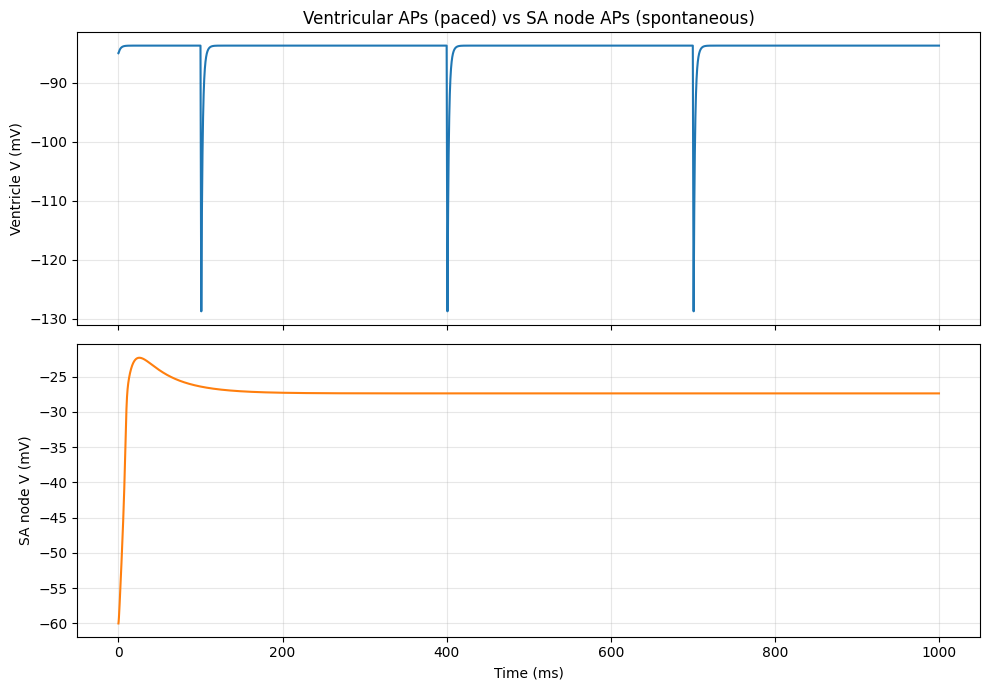

In [5]:
# Time axis
dt = 0.02  # ms
t_end = 1000.0
t = np.arange(0, t_end+dt, dt)

# Ventricular stimulus protocol: brief current pulses to elicit APs
Iapp_vent = np.zeros_like(t)
for start in [100, 400, 700]:
    Iapp_vent[(t>=start) & (t<start+1.0)] = -60.0  # µA/cm^2 (negative inward depolarizing)

Vv, rec_v = simulate_ventricle(t, Iapp_vent)
Vs, rec_s = simulate_SAN(t)

fig,axs = plt.subplots(2,1,figsize=(10,7), sharex=True)
axs[0].plot(t, Vv, 'C0'); axs[0].set_ylabel('Ventricle V (mV)'); axs[0].grid(alpha=0.3)
axs[0].set_title('Ventricular APs (paced) vs SA node APs (spontaneous)')
axs[1].plot(t, Vs, 'C1'); axs[1].set_ylabel('SA node V (mV)'); axs[1].set_xlabel('Time (ms)'); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Inspect ionic currents and gates
Try toggling conductances (e.g., set `vent_params.gK1=0` or `san_params.gf=0`) and re-run to see effects on resting potential and pacemaking.


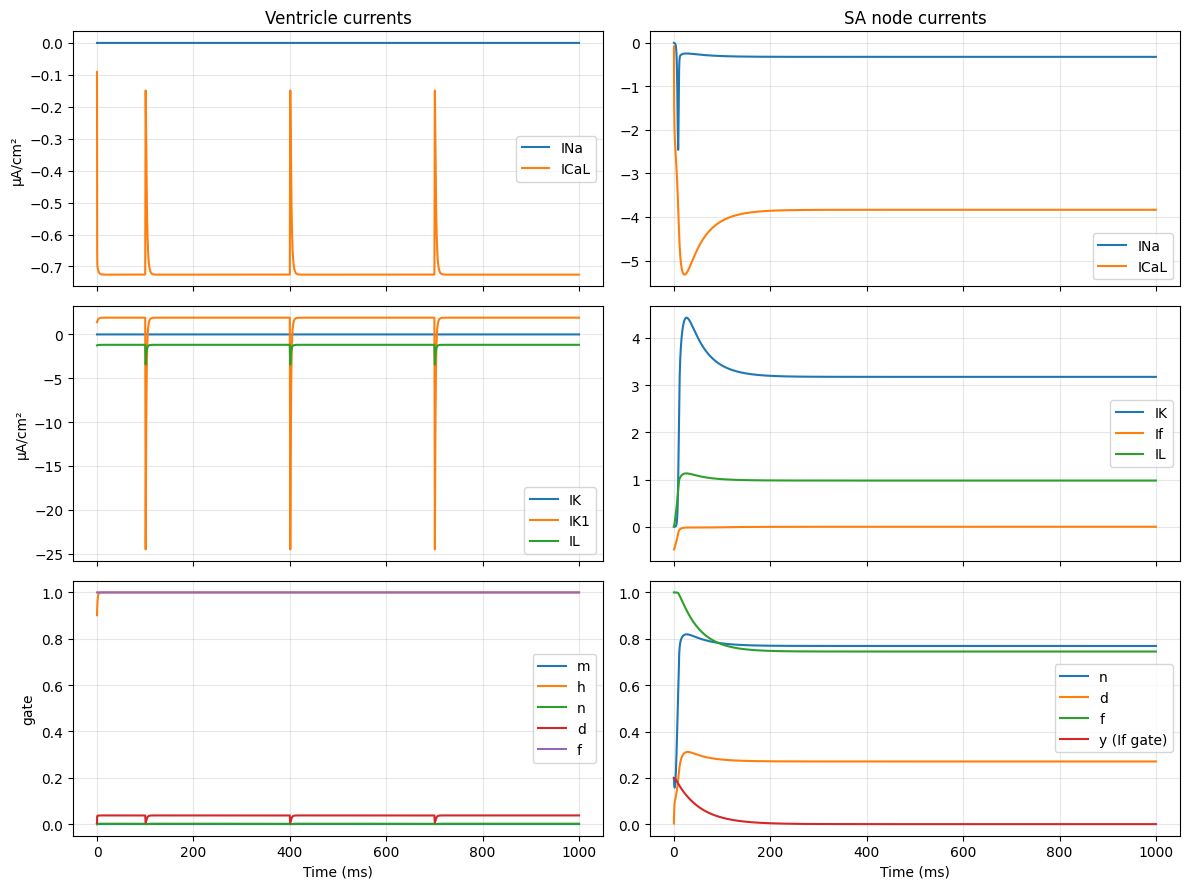

In [6]:
fig,axs = plt.subplots(3,2,figsize=(12,9), sharex='col')
axs[0,0].plot(t[:-1], rec_v['INa'], label='INa'); axs[0,0].plot(t[:-1], rec_v['ICaL'], label='ICaL'); axs[0,0].legend(); axs[0,0].set_ylabel('µA/cm²'); axs[0,0].set_title('Ventricle currents')
axs[1,0].plot(t[:-1], rec_v['IK'], label='IK'); axs[1,0].plot(t[:-1], rec_v['IK1'], label='IK1'); axs[1,0].plot(t[:-1], rec_v['IL'], label='IL'); axs[1,0].legend(); axs[1,0].set_ylabel('µA/cm²')
axs[2,0].plot(t[:-1], rec_v['m'], label='m'); axs[2,0].plot(t[:-1], rec_v['h'], label='h'); axs[2,0].plot(t[:-1], rec_v['n'], label='n'); axs[2,0].plot(t[:-1], rec_v['d'], label='d'); axs[2,0].plot(t[:-1], rec_v['f'], label='f'); axs[2,0].legend(); axs[2,0].set_ylabel('gate'); axs[2,0].set_xlabel('Time (ms)')

axs[0,1].plot(t[:-1], rec_s['INa'], label='INa'); axs[0,1].plot(t[:-1], rec_s['ICaL'], label='ICaL'); axs[0,1].legend(); axs[0,1].set_title('SA node currents')
axs[1,1].plot(t[:-1], rec_s['IK'], label='IK'); axs[1,1].plot(t[:-1], rec_s['If'], label='If'); axs[1,1].plot(t[:-1], rec_s['IL'], label='IL'); axs[1,1].legend()
axs[2,1].plot(t[:-1], rec_s['n'], label='n'); axs[2,1].plot(t[:-1], rec_s['d'], label='d'); axs[2,1].plot(t[:-1], rec_s['f'], label='f'); axs[2,1].plot(t[:-1], rec_s['y'], label='y (If gate)'); axs[2,1].legend(); axs[2,1].set_xlabel('Time (ms)')
for ax in axs.flat: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Tasks
1. **SAN pacemaking:** set `san_params.gf=0` (block If) and compensate by slightly increasing `gCaL`. Does spontaneous rate drop or disappear?

2. **Resting potential control:** set `vent_params.gK1=0`. What happens to the ventricular resting potential and excitability?

3. **Upstroke source:** set `vent_params.gNa=0` and increase `gCaL`. Compare upstroke speed and peak voltage to SAN.

4. **Rate control:** in the SAN model, shift the If gate half-activation by editing `ab_y_If` (e.g., from `+70` to `+60`). How does cycle length change?


## Notes on the simplifications
- This is a compact, didactic HH formulation (alpha–beta **dynamics** for all gates). Conductance magnitudes and gate kinetics are tuned to generate qualitatively correct behaviors without reproducing a specific species’ dataset.
- For detailed and validated ionic models, see the **Beeler–Reuter ventricular** model and **Yanagihara–Noma–Irisawa SAN** model; these include explicit experimental rate formulations and additional currents.


## References (read first if you go deeper)
- Beeler GW, Reuter H. "Reconstruction of the action potential of ventricular myocardial fibres" (J Physiol, 1977).
- Yanagihara K, Noma A, Irisawa H. "Reconstruction of sino-atrial node pacemaker potential based on voltage clamp experiments" (Jpn J Physiol, 1980).
- DiFrancesco D. "The Role of the Funny Current in Pacemaker Activity" (Circ Res, 2010).
- Overviews of If properties and SAN physiology (see your course notes / review papers).
